# Examples for Day 3

In [1]:
# initialization
%matplotlib inline
from warnings import filterwarnings
filterwarnings("ignore")

In [3]:
# %load ml29.py
# Random Forest Classification
from pandas import read_csv
from sklearn.model_selection import train_test_split as split
from sklearn.ensemble import RandomForestClassifier
df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, test_size=0.25, random_state=42)
rfc = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print(f'Accuracy: {rfc.score(X_test, y_test):.2%}')


Accuracy: 72.96%


In [4]:
rfc.feature_importances_

array([0.0734176 , 0.04497372, 0.00502681, 0.16686083, 0.02894774,
       0.00998191, 0.02221773, 0.02396129, 0.0287488 , 0.02394664,
       0.00874587, 0.00850789, 0.01196482, 0.11295083, 0.04719985,
       0.06216532, 0.02557274, 0.02968224, 0.12291459, 0.05677356,
       0.08543923])

In [5]:
for i in range(21):
    print(f'{X.columns[i]}: {rfc.feature_importances_[i]}')

HighBP: 0.07341759558941907
HighChol: 0.0449737190869487
CholCheck: 0.005026810913891252
BMI: 0.16686082720440568
Smoker: 0.02894774452760592
Stroke: 0.009981907936846498
HeartDiseaseorAttack: 0.022217734981306518
PhysActivity: 0.02396129275284931
Fruits: 0.02874880175972216
Veggies: 0.023946635216084082
HvyAlcoholConsump: 0.008745873136014439
AnyHealthcare: 0.008507885200406125
NoDocbcCost: 0.011964815091037225
GenHlth: 0.11295082725190225
MentHlth: 0.04719984524960472
PhysHlth: 0.06216532340731731
DiffWalk: 0.025572736069114838
Gender: 0.029682237396174174
Age: 0.12291459469413338
Education: 0.0567735594436365
Income: 0.08543923309157979


In [7]:
# %load ml30.py
# Gradient Boosting Tree Classification
from pandas import read_csv
from sklearn.model_selection import train_test_split as split
from sklearn.ensemble import GradientBoostingClassifier
df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, test_size=0.25, random_state=42)
gbc = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)
print(f'Accuracy: {gbc.score(X_test, y_test):.2%}')

Accuracy: 73.93%


In [8]:
gbc.feature_importances_

array([0.18884751, 0.06219836, 0.00667927, 0.13905931, 0.00072927,
       0.00657157, 0.01929739, 0.00150878, 0.00384602, 0.00152533,
       0.01322851, 0.00253574, 0.00208542, 0.3925404 , 0.00727022,
       0.01033436, 0.00193922, 0.00926209, 0.09908124, 0.00851539,
       0.02294459])

In [10]:
# %load ml31.py
# Voting Classifier
from pandas import read_csv
from sklearn.model_selection import train_test_split as split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, test_size=0.25, random_state=42)

clf1 = LogisticRegression()
clf2 = GaussianNB()
clf3 = SVC()
vtc = VotingClassifier(estimators=[('lgr', clf1), ('gnb', clf2), ('svc', clf3)], voting='hard')
vtc.fit(X_train, y_train)
print(f"Accuracy: {vtc.score(X_test, y_test):.2%}")

Accuracy: 73.19%


In [12]:
# %load ml32.py
# MLP Classification
from pandas import read_csv
from sklearn.model_selection import train_test_split as split
from sklearn.neural_network import MLPClassifier
df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, test_size=0.25, random_state=42)
mlp = MLPClassifier(random_state=42).fit(X_train, y_train)
print(f'Accuracy: {mlp.score(X_test, y_test):.2%}')


Accuracy: 72.91%


In [13]:
from sklearn.preprocessing import MinMaxScaler
scl = MinMaxScaler()
Xs_train = scl.fit_transform(X_train)
Xs_test = scl.transform(X_test)

mlp2 = MLPClassifier(random_state=42).fit(Xs_train, y_train)
print(f'Accuracy: {mlp2.score(Xs_test, y_test):.2%}')

Accuracy: 73.81%


In [15]:
# %load ml33.py
# Hyperparameter tuning with grid search
from pandas import read_csv
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, train_test_split as split, KFold
df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, random_state=42)
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train, y_train)
print(f'Accuracy without tuning: {model1.score(X_test, y_test):.2%}')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
params = dict(criterion=['gini', 'entropy'], max_leaf_nodes=range(2, 21))
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=kf, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)
print(grid.best_params_)
model2 = DecisionTreeClassifier(**grid.best_params_, random_state=42).fit(X_train, y_train)
print(f'Accuracy with tuning: {model2.score(X_test, y_test):.2%}')


Accuracy without tuning: 64.25%
Fitting 5 folds for each of 38 candidates, totalling 190 fits
{'criterion': 'gini', 'max_leaf_nodes': 18}
Accuracy with tuning: 71.27%


In [17]:
# %load ml34.py
from pandas import read_csv
from sklearn.model_selection import train_test_split as split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, test_size=0.25, random_state=42)
pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression())])
pipe.fit(X_train, y_train)
print(f'Accuracy: {pipe.score(X_test, y_test):.2%}')

Accuracy: 73.53%


In [18]:
pipe

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [20]:
# %load ml35.py
# Use GridSearchCV with pipeline
from pandas import read_csv
from sklearn.model_selection import train_test_split as split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline

df = read_csv('data/cdc_diabetes_small.csv')
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = split(X, y, test_size=0.25, random_state=42)

pipe2 = Pipeline([('scaler', None), ('clf', KNeighborsClassifier())])
params = {}
params['scaler'] = [None, MinMaxScaler(), StandardScaler(), RobustScaler()]
params['clf'] = [KNeighborsClassifier(), LogisticRegression(), SVC()]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe2, params, cv=kf, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print(grid.best_params_)

best_pipe = grid.best_estimator_
best_pipe.fit(X_train, y_train)
print(f'Accuracy: {best_pipe.score(X_test, y_test):.2%}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'clf': LogisticRegression(), 'scaler': RobustScaler()}
Accuracy: 73.64%


In [21]:
pipe2

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None


In [22]:
best_pipe

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


[]

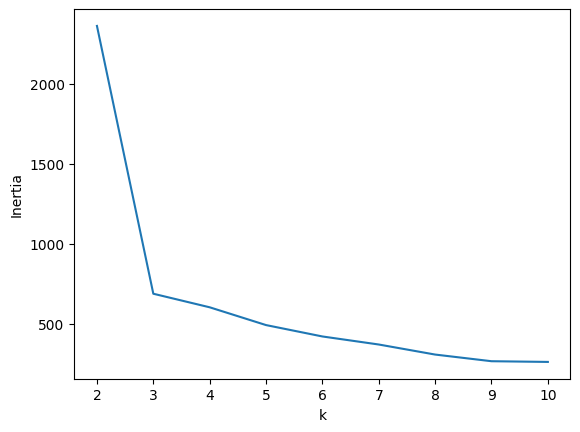

In [27]:
# %load ml36.py
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
X, y = make_blobs(centers=3, cluster_std=2, random_state=42)
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k).fit(X)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.plot()


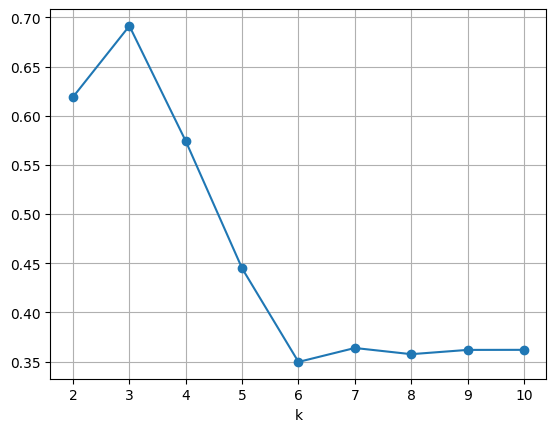

In [28]:
from sklearn.metrics import silhouette_score

sscores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10).fit(X)
    sscores.append(silhouette_score(X, km.labels_))

plt.plot(range(2, 11), sscores, marker='o')
plt.xlabel('k')
plt.grid(True)
plt.show()

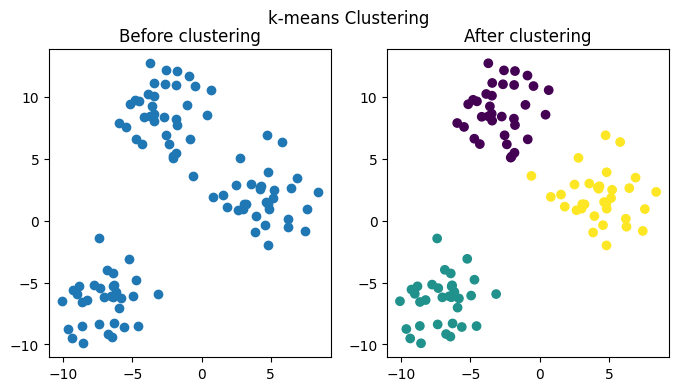

In [30]:
# %load ml37.py
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
X, y = make_blobs(centers=3, cluster_std=2, random_state=42)
km = KMeans(n_clusters=3, n_init=10).fit(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('k-means Clustering')
ax1.scatter(X[:, 0], X[:, 1])
ax1.set_title('Before clustering')
ax2.scatter(X[:, 0], X[:, 1], c=km.labels_)
ax2.set_title('After clustering')
plt.show()


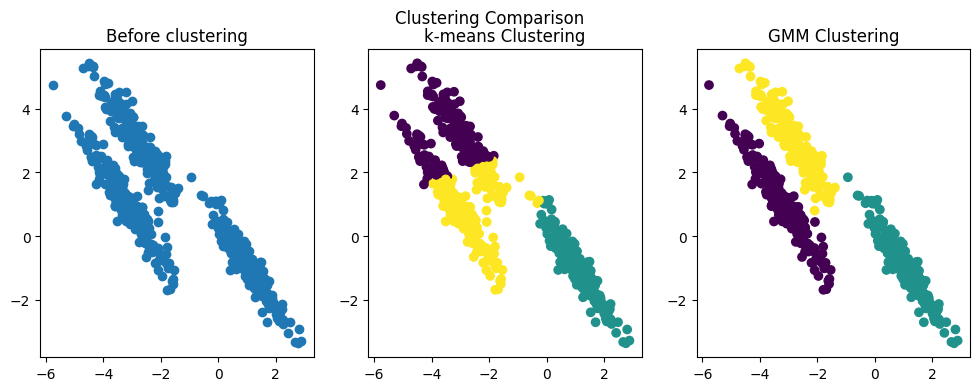

In [32]:
# %load ml39.py
# Clustering of non-spherical data points
from pandas import read_csv
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

X = read_csv("data/long_clusters.csv").values
km = KMeans(n_clusters=3, n_init=10).fit(X)
labels = GaussianMixture(n_components=3).fit_predict(X)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Clustering Comparison')
ax1.scatter(X[:, 0], X[:, 1])
ax1.set_title('Before clustering')
ax2.scatter(X[:, 0], X[:, 1], c=km.labels_)
ax2.set_title('k-means Clustering')
ax3.scatter(X[:, 0], X[:, 1], c=labels)
ax3.set_title('GMM Clustering')
plt.show()

In [35]:
# %load ml40.py
# Dimensionality reduction using PCA
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

pca = PCA(n_components=32)
X_reduced = pca.fit_transform(X)

print(X.shape, X_reduced.shape)
print(pca.explained_variance_ratio_.sum())


(1797, 64) (1797, 32)
0.9663542069634703
